# MSE250 Lab 2 Tensile Testing

## License

Copyright © 2026 Philip Eisenlohr and contributors.

Unless otherwise noted, instructional text, documentation, figures, and other non-code content in this notebook are licensed under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/). Python code is licensed under the [BSD 3-Clause License](https://github.com/mseMSU/Notebooks-pub/blob/main/LICENSE-CODE.md). Third-party materials remain subject to their respective licenses. Use does not imply endorsement by Michigan State University.

## Tasks

* Generate engineering stress–engineering strain curves and trues tress–true strain curves for dogbone samples tested in uniaxial tension using the Instron mechanical testing machine in the MSE 250 laboratory.
* Determine the tensile properties of several metal alloy materials.


## Derivation of true stress and strain from engineering stress and strain

Provide a comprehensive derivation of the relations

$$
\sigma_\text{T} = \sigma_0 \left(1+\epsilon_0\right)
\\
\epsilon_\text{T} = \ln \left(1+\epsilon_0\right),
$$
where subscripts "T" and "0" denote "true" and "engineering" quantities, respectively.

**Hint**: assume constant volume, i.e. $V_0 = V$.

$$
\sigma_\text{T}
= \ldots \text{fill in the blank} \ldots
= \sigma_0\left(1+\epsilon_0\right)
\\
\epsilon_\text{T}
= \ldots \text{fill in the blank} \ldots
= \ln \left(1+\epsilon_0\right)
$$

## Import useful Python modules

In [43]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px

from matplotlib import pyplot as plt

## Specimen geometry

In [33]:
geometry = pd.DataFrame(
		index=['Al2024', 'Al6061', 'steel', 'brass'],    # descriptive names of samples
		data={
			'gauge/mm': [12,23,34,45],                   # gauge length in mm of all samples
			'area/mm^2': [11,22,33,44],                  # cross-sectional area of all samples
			})

geometry

,gauge/mm,area/mm^2
Al2024,12,11
Al6061,23,22
steel,34,33
brass,45,44


Accessing geometry data in above data frame can be done in one of two ways.

In [3]:
print(f"The cross-section of the steel sample is {geometry['area']['steel']}.")
print(f"The cross-section of the steel sample is {geometry.loc['steel','area']}.")


The cross-section of the steel sample is 33.
The cross-section of the steel sample is 33.


## Measured load–displacement data

The Instron tensile machine exports the data for a test in a specific file format that looks like (check with a text editor!)
```
Results Table 1
,Specimen label,Width,Thickness,Length,Tensile strain (Displacement) at Break (Standard),Maximum Tensile stress
,,(mm),(mm),(mm),(%),(MPa)
"1","AL2024_1","12.80","1.60","73.66","19.80","487.66"
"2","AL2024_2_1","12.95","1.63","72.39","7.05","442.29"
"3","AL2024_2_2","12.70","1.50","79.25","7.66","532.53"
"4","AL2024_2_3","12.42","1.50","83.41","7.35","556.50"

1,Time,Displacement,Force
,(s),(mm),(N)
"","0.0000","0.0000","675.2703"
"","0.1000","0.0048","722.1011"
"","0.2000","0.0184","871.9633"
```

Please be aware that each of the exported files contains **four different sections** that you need to **cut out into four separate files**!

We can use the `read_csv` method of `pandas` to read such files and translate them into a dataframe.

* in above example, data that we want to use starts after row 10, therefore, we skip the first ten rows
* the first column is always empty, so we ignore it
* we provide our own names for the three columns

In [29]:
df = pd.DataFrame()                 # empty data frame
for filename,material in [
	('Al2024_1','Al2024'),
	('brass_1','brass'),
	]:
	tmp = pd.read_csv(              # read file
		filename+'.csv',
		skiprows=10,
		names=['Time/s','Displacement/mm','Force/N'],
		usecols=[1,2,3],
		)
	tmp['material'] = material      # add column indicating which material this is
	df = pd.concat([df,tmp])        # add new data to existing entries

df

,Time/s,Displacement/mm,Force/N,material
0,0.770,0.1476,2190.6357,Al2024
1,0.870,0.1677,2376.1462,Al2024
2,0.970,0.1895,2560.0254,Al2024
3,1.070,0.2099,2732.2812,Al2024
4,1.170,0.2318,2923.3376,Al2024
...,...,...,...,...
1388,137.769,29.1445,9124.9814,brass
1389,137.770,29.1447,8762.5508,brass
1390,137.771,29.1450,8397.7148,brass
1391,137.772,29.1452,8032.0596,brass


## Calculate stress and strain from force and displacement

We use the known relations
$$
\epsilon_0 = \frac{\Delta L}{L_0} \qquad\text{and}\qquad \epsilon_\text{T} = \ln\left(\frac{L}{L_0}\right)
\\[4ex]
\sigma_0 = \frac{F}{A_0} \qquad\text{and}\qquad \sigma_\text{T} = \frac{F}{A} = \frac{F\,L}{A_0\,L_0}
$$
to calculate these quantities.

Note that you can make use of the `material` column to select the corresponding geometric data from the `geometry` dataframe created above.

In [36]:
df['engstrain'] = df['Displacement/mm']/geometry['gauge/mm'][df['material']].values
df['engstress/MPa'] = df['Force/N']/geometry['area/mm^2'][df['material']].values


TypeError: cannot unpack non-iterable Axes object

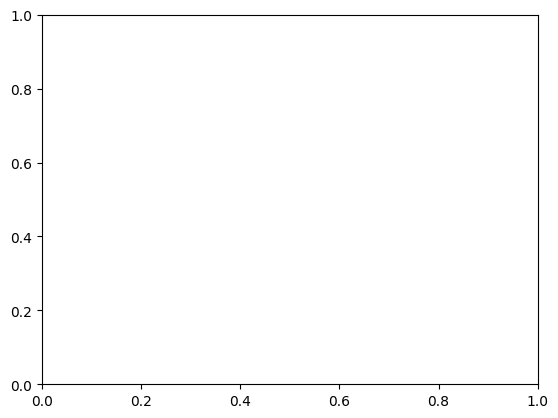

In [44]:
fig,ax = plt.subplot()
ax = sns.lineplot(
	data=df,
	x='engstrain',
	y='engstress/MPa',
	hue='material',
)


In [37]:
px.line(df,
		x='engstrain',
		y='engstress/MPa',
		color='material',
		)